# Quickstart: Conditional Feature Importance with xeries    

This notebook demonstrates how to use xeries for computing conditional feature importance in multi-time series forecasting.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

## 1. Create Sample Multi-Series Data

We'll create synthetic time series data for multiple stores with hourly observations.

In [2]:
np.random.seed(42)
n_periods = 200
n_series = 3

# Create date range
dates = pd.date_range('2023-01-01', periods=n_periods, freq='h')

# Generate series data
series_data = {}
for i in range(n_series):
    series_id = f'store_{i+1:03d}'  
    base = np.random.randn() * 10
    trend = np.linspace(0, 5, n_periods)
    seasonal = 5 * np.sin(2 * np.pi * np.arange(n_periods) / 24)
    noise = np.random.randn(n_periods) * 0.5
    series_data[series_id] = base + trend + seasonal + noise

df = pd.DataFrame(series_data, index=dates)
print(f"Data shape: {df.shape}")
df.head()

Data shape: (200, 3)


,store_001,store_002,store_003
2023-01-01 00:00:00,4.898009,6.149371,0.075927
2023-01-01 01:00:00,6.610207,7.453967,1.146625
2023-01-01 02:00:00,8.278908,7.469262,2.914113
2023-01-01 03:00:00,8.460976,8.749844,3.129538
2023-01-01 04:00:00,9.280703,10.295992,4.411877


## 2. Create Lag Features Manually

For this example, we'll manually create lag features to demonstrate tcpfi without requiring skforecast.

X shape: (585, 5)
y shape: (585,)
                                   lag_1      lag_2      lag_3      lag_4  \
level     date                                                              
store_001 2023-01-01 05:00:00   9.280703   8.460976   8.278908   6.610207   
          2023-01-01 06:00:00  10.712005   9.280703   8.460976   8.278908   
          2023-01-01 07:00:00  10.501613  10.712005   9.280703   8.460976   
          2023-01-01 08:00:00   9.737913  10.501613  10.712005   9.280703   
          2023-01-01 09:00:00   9.769554   9.737913  10.501613  10.712005   

                                  lag_5  
level     date                           
store_001 2023-01-01 05:00:00  4.898009  
          2023-01-01 06:00:00  6.610207  
          2023-01-01 07:00:00  8.278908  
          2023-01-01 08:00:00  8.460976  
          2023-01-01 09:00:00  9.280703  


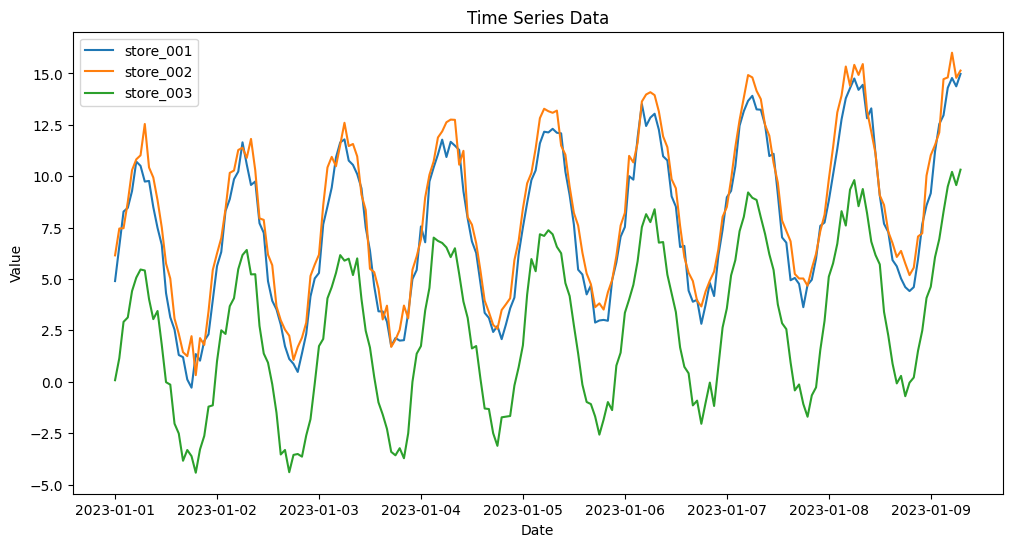

In [3]:
def create_lag_features(series: pd.Series, n_lags: int = 5) -> pd.DataFrame:
    """Create lag features from a time series."""
    df = pd.DataFrame()
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = series.shift(lag)
    df['target'] = series
    return df.dropna()

# Create features for each series and combine
n_lags = 5
all_data = []

for series_id in df.columns:
    series_df = create_lag_features(df[series_id], n_lags)
    series_df['series_id'] = series_id
    series_df.index = pd.MultiIndex.from_arrays(
        [[series_id] * len(series_df), series_df.index],
        names=['level', 'date']
    )
    all_data.append(series_df)

combined = pd.concat(all_data)
X = combined[[f'lag_{i}' for i in range(1, n_lags + 1)]]
y = combined['target']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(X.head())

#Plotting the data
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for series_id in df.columns:
    plt.plot(df.index, df[series_id], label=series_id)
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

## 3. Train a Global Model

In [4]:
# Train a RandomForest model
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42
)
model.fit(X.values, y.values)

# Check baseline performance
predictions = model.predict(X.values)
mse = np.mean((y.values - predictions) ** 2)
print(f"Training MSE: {mse:.4f}")

Training MSE: 0.1250


## 4. Compute Conditional Permutation Importance

Now let's use tcpfi to compute conditional permutation importance with automatic tree-based partitioning (cs-PFI).

In [5]:
from xeries import ConditionalPermutationImportance

# Create explainer with automatic strategy (tree-based cs-PFI)
explainer = ConditionalPermutationImportance(
    model=model,
    metric='mse',
    strategy='auto',
    n_repeats=3,
    n_jobs=1,
    random_state=42,
)

# Compute importance
result = explainer.explain(X, y)

# Display results
result.to_dataframe()

c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegre

,feature,importance,std
0,lag_1,2.852563,0.088752
1,lag_2,0.170922,0.005247
4,lag_5,0.145798,0.006413
3,lag_4,0.143364,0.014596
2,lag_3,0.101015,0.008618


## 5. Visualize Results

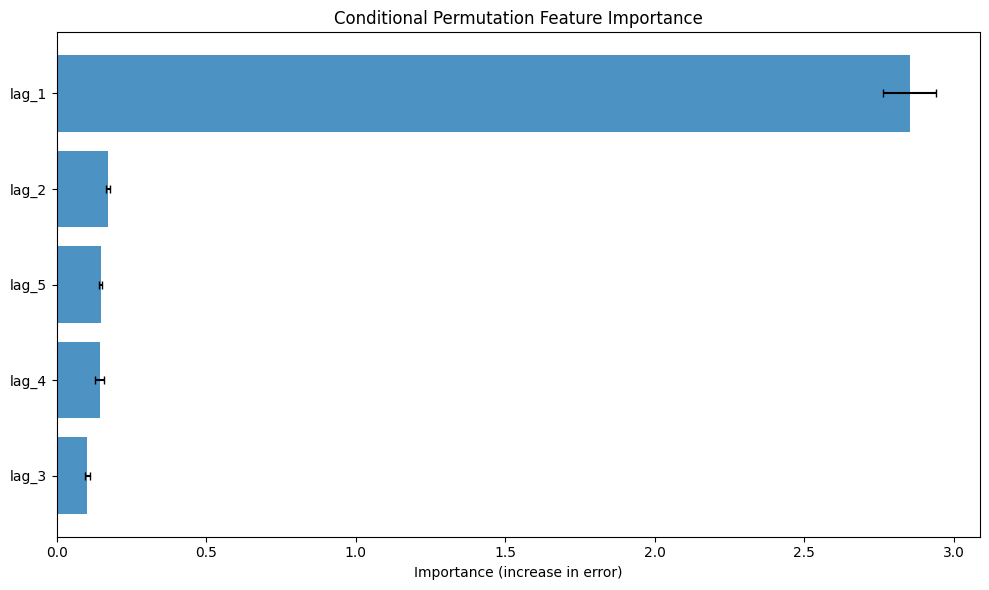

In [6]:
from xeries.visualization import plot_importance_bar

fig, ax = plot_importance_bar(result, title='Conditional Permutation Feature Importance')

## 6. Using Manual Groups

You can also define custom groups based on domain knowledge.

In [8]:
from xeries import ManualPartitioner

# Define groups based on domain knowledge
mapping = {
    'store_001': 'region_A',
    'store_002': 'region_B',
    'store_003': 'region_A',
}

partitioner = ManualPartitioner(mapping, series_col='level')

# Create explainer with manual partitioner
explainer_manual = ConditionalPermutationImportance(
    model=model,
    metric='mse',
    strategy='manual',
    partitioner=partitioner,
    n_repeats=3,
    n_jobs=1,
    random_state=42,
)

result_manual = explainer_manual.explain(X, y)
result_manual.to_dataframe()

c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegre

,feature,importance,std
0,lag_1,38.217226,1.788061
3,lag_4,0.578732,0.017619
4,lag_5,0.552823,0.042007
1,lag_2,0.216099,0.006519
2,lag_3,0.162267,0.007702


## 7. Compare Methods

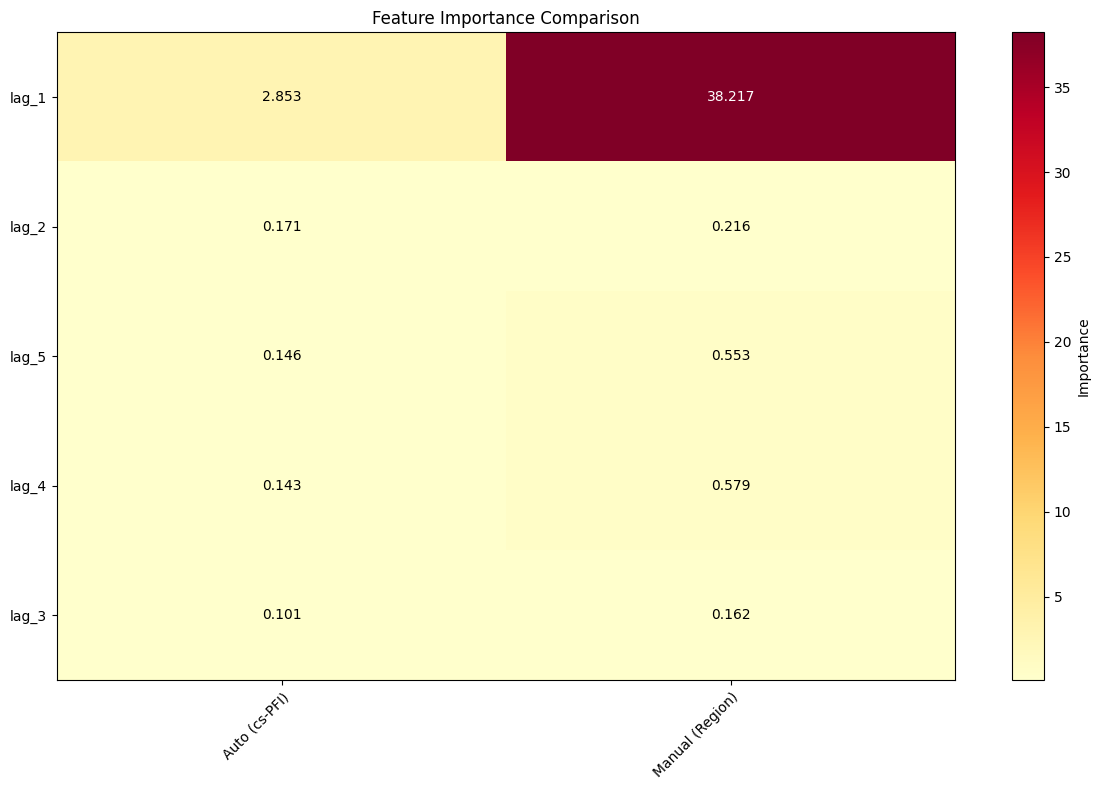

In [9]:
from xeries.visualization import plot_importance_heatmap

results = {
    'Auto (cs-PFI)': result,
    'Manual (Region)': result_manual,
}

fig, ax = plot_importance_heatmap(results, title='Feature Importance Comparison')

## Summary

In this notebook, we demonstrated:

1. Creating multi-series time series data with lag features
2. Training a global RandomForest model
3. Computing conditional permutation importance using:
   - Automatic tree-based partitioning (cs-PFI)
   - Manual domain-based grouping
4. Visualizing and comparing results

The key insight is that `lag_1` (most recent lag) typically has the highest importance, which aligns with the autocorrelation structure of time series data.